# Deep Learning Fundamentals

Comprehensive coverage of deep learning concepts with **NumPy (from scratch)** and **PyTorch (production-ready)** implementations. Topics: perceptrons, activation functions, backpropagation, vanishing gradients, regularization, and modern training techniques.

📺 **Video Lecture:** [https://youtu.be/96bvudFrdhg](https://youtu.be/96bvudFrdhg)

In [16]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification, make_moons, make_circles
from sklearn.preprocessing import StandardScaler
from matplotlib.patches import Circle

np.random.seed(42)
torch.manual_seed(42)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

print('NumPy version:', np.__version__)
print('PyTorch version:', torch.__version__)
print('GPU available:', torch.cuda.is_available())

NumPy version: 2.4.4
PyTorch version: 2.11.0
GPU available: False


## 1. Perceptron Implementation

### NumPy Implementation (from scratch)

In [17]:
class PerceptronNumPy:
    """Simple perceptron with sigmoid activation using NumPy"""
    def __init__(self, input_size):
        self.weights = np.random.randn(input_size) * 0.01
        self.bias = 0
    
    def sigmoid(self, x):
        return 1 / (1 + np.exp(-np.clip(x, -500, 500)))
    
    def forward(self, X):
        self.z = np.dot(X, self.weights) + self.bias
        self.activation = self.sigmoid(self.z)
        return self.activation
    
    def backward(self, X, y, learning_rate=0.01):
        m = X.shape[0]
        dz = self.activation - y
        dw = (1/m) * np.dot(X.T, dz)
        db = (1/m) * np.sum(dz)
        self.weights -= learning_rate * dw
        self.bias -= learning_rate * db
        return np.mean((self.activation - y)**2)

# Train on synthetic data
X, y = make_classification(n_samples=100, n_features=2, n_informative=2,
                          n_redundant=0, random_state=42)
scaler = StandardScaler()
X = scaler.fit_transform(X)

perceptron = PerceptronNumPy(input_size=2)
losses_numpy = []

for epoch in range(100):
    perceptron.forward(X)
    loss = perceptron.backward(X, y, learning_rate=0.1)
    losses_numpy.append(loss)

predictions = perceptron.forward(X)
accuracy = np.mean((predictions > 0.5) == y)
print(f'NumPy Perceptron - Training Accuracy: {accuracy:.4f}')

NumPy Perceptron - Training Accuracy: 0.9600


### PyTorch Implementation (torch.nn.Linear)

PyTorch Perceptron - Training Accuracy: 0.9600


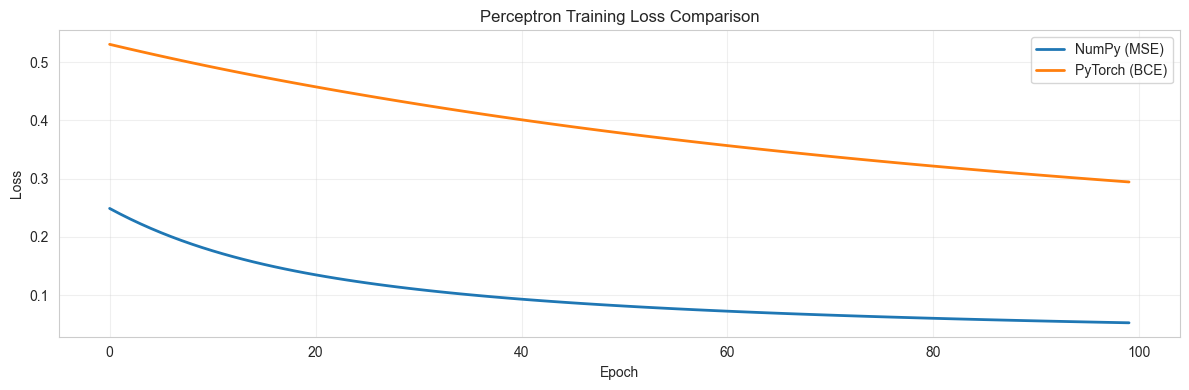

In [18]:
class PerceptronTorch(nn.Module):
    """Perceptron using PyTorch nn.Linear"""
    def __init__(self, input_size):
        super().__init__()
        self.linear = nn.Linear(input_size, 1)
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        return self.sigmoid(self.linear(x))

# Convert data to PyTorch tensors
X_torch = torch.FloatTensor(X)
y_torch = torch.FloatTensor(y).reshape(-1, 1)

# Model, loss, optimizer
model_torch = PerceptronTorch(input_size=2)
criterion = nn.BCELoss()
optimizer = optim.Adam(model_torch.parameters(), lr=0.01)

losses_torch = []
for epoch in range(100):
    optimizer.zero_grad()
    outputs = model_torch(X_torch)
    loss = criterion(outputs, y_torch)
    loss.backward()
    optimizer.step()
    losses_torch.append(loss.item())

with torch.no_grad():
    predictions_torch = (model_torch(X_torch) > 0.5).float()
    accuracy_torch = (predictions_torch == y_torch).float().mean().item()
    print(f'PyTorch Perceptron - Training Accuracy: {accuracy_torch:.4f}')

# Comparison plot
plt.figure(figsize=(12, 4))
plt.plot(losses_numpy, label='NumPy (MSE)', linewidth=2)
plt.plot(losses_torch, label='PyTorch (BCE)', linewidth=2)
plt.title('Perceptron Training Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Activation Functions

### NumPy Implementations

In [19]:
# NumPy activation functions
def sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -500, 500)))

def tanh(x):
    return np.tanh(x)

def relu(x):
    return np.maximum(0, x)

def leaky_relu(x, alpha=0.01):
    return np.where(x > 0, x, alpha * x)

def gelu(x):
    """GELU approximation"""
    return x * (1 + np.tanh(np.sqrt(2/np.pi) * (x + 0.044715 * x**3))) / 2

def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)

def tanh_derivative(x):
    return 1 - np.tanh(x)**2

def relu_derivative(x):
    return (x > 0).astype(float)

print('NumPy activation functions defined.')

NumPy activation functions defined.


### Visualize All Activations: NumPy vs PyTorch

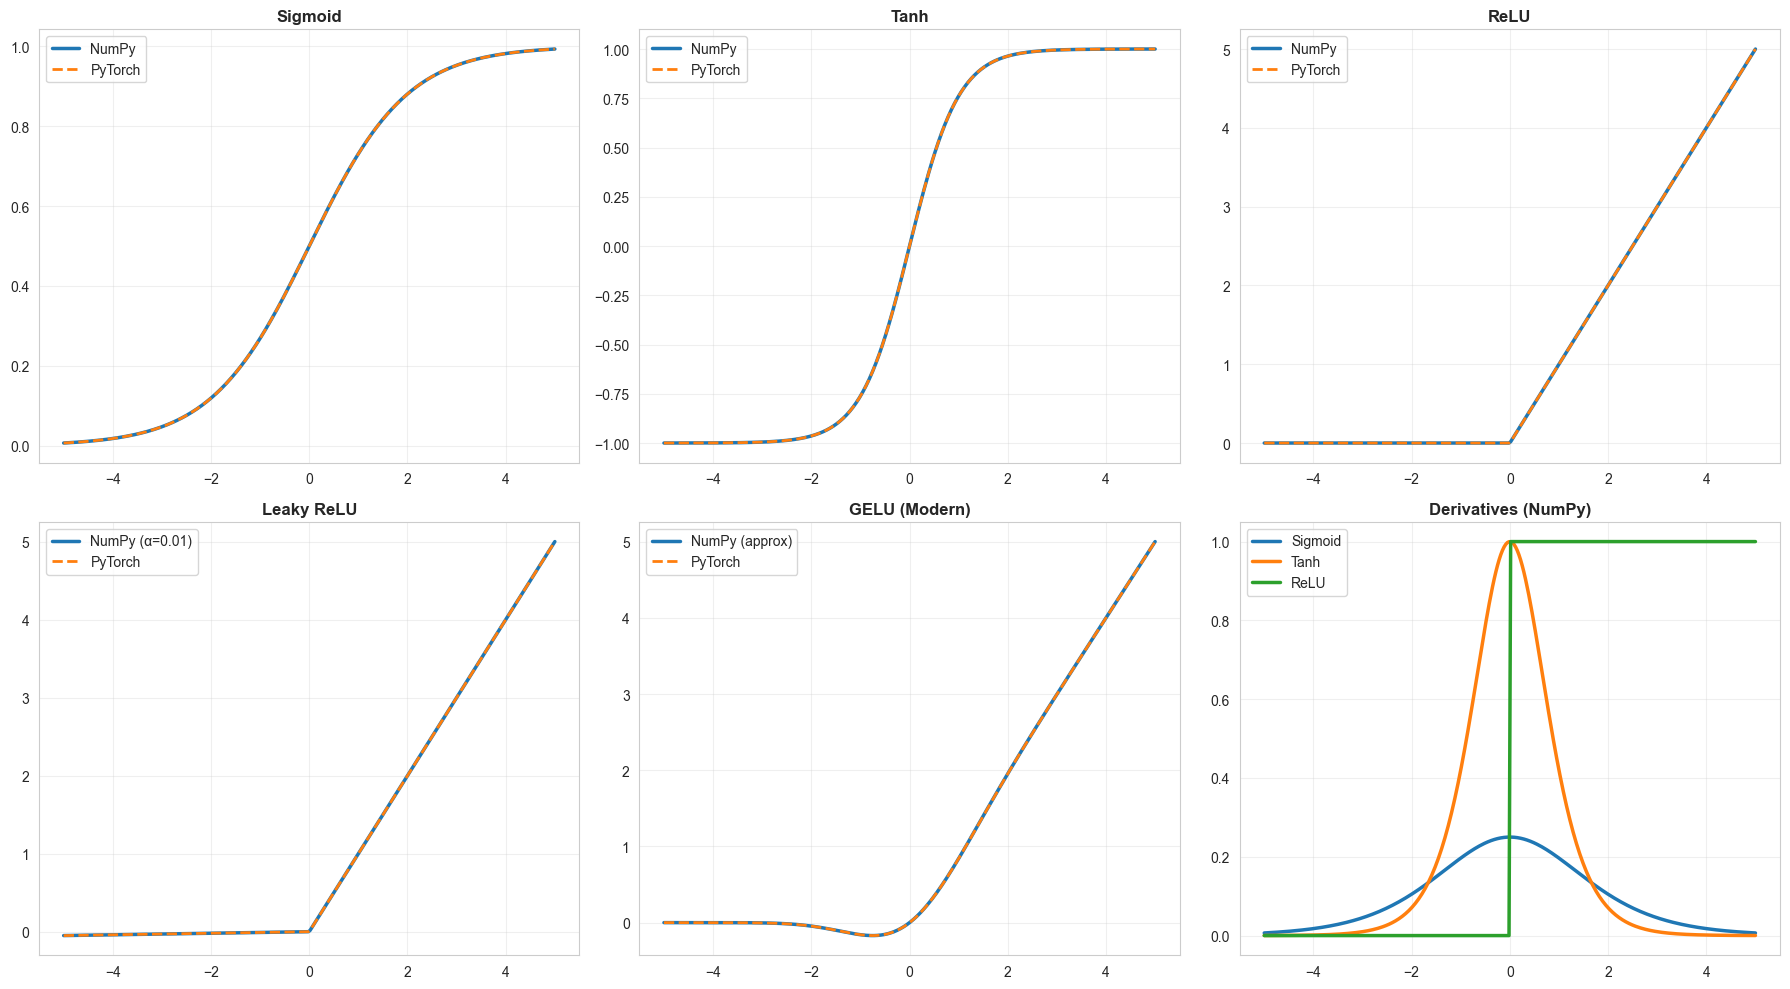

Activation functions comparison complete.


In [20]:
x_np = np.linspace(-5, 5, 300)
x_torch = torch.FloatTensor(x_np)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Row 1: Activations
# Sigmoid
axes[0, 0].plot(x_np, sigmoid(x_np), linewidth=2.5, label='NumPy')
axes[0, 0].plot(x_np, torch.sigmoid(x_torch).numpy(), linewidth=2, linestyle='--', label='PyTorch')
axes[0, 0].set_title('Sigmoid', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

# Tanh
axes[0, 1].plot(x_np, tanh(x_np), linewidth=2.5, label='NumPy')
axes[0, 1].plot(x_np, torch.tanh(x_torch).numpy(), linewidth=2, linestyle='--', label='PyTorch')
axes[0, 1].set_title('Tanh', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()

# ReLU
axes[0, 2].plot(x_np, relu(x_np), linewidth=2.5, label='NumPy')
axes[0, 2].plot(x_np, torch.relu(x_torch).numpy(), linewidth=2, linestyle='--', label='PyTorch')
axes[0, 2].set_title('ReLU', fontsize=12, fontweight='bold')
axes[0, 2].grid(True, alpha=0.3)
axes[0, 2].legend()

# Row 2: Leaky ReLU and GELU
# Leaky ReLU
axes[1, 0].plot(x_np, leaky_relu(x_np, 0.01), linewidth=2.5, label='NumPy (α=0.01)')
axes[1, 0].plot(x_np, torch.nn.functional.leaky_relu(x_torch, 0.01).numpy(), linewidth=2, linestyle='--', label='PyTorch')
axes[1, 0].set_title('Leaky ReLU', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

# GELU
axes[1, 1].plot(x_np, gelu(x_np), linewidth=2.5, label='NumPy (approx)')
axes[1, 1].plot(x_np, torch.nn.functional.gelu(x_torch).numpy(), linewidth=2, linestyle='--', label='PyTorch')
axes[1, 1].set_title('GELU (Modern)', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()

# Derivatives
axes[1, 2].plot(x_np, sigmoid_derivative(x_np), linewidth=2.5, label='Sigmoid')
axes[1, 2].plot(x_np, tanh_derivative(x_np), linewidth=2.5, label='Tanh')
axes[1, 2].plot(x_np, relu_derivative(x_np), linewidth=2.5, label='ReLU')
axes[1, 2].set_title('Derivatives (NumPy)', fontsize=12, fontweight='bold')
axes[1, 2].grid(True, alpha=0.3)
axes[1, 2].legend()

plt.tight_layout()
plt.show()

print('Activation functions comparison complete.')

## 3. Multi-Layer Network from Scratch (NumPy)

### Training on XOR / Spiral Dataset

In [21]:
class TwoLayerNNNumPy:
    """2-layer neural network from scratch with NumPy"""
    def __init__(self, input_size, hidden_size, output_size):
        self.W1 = np.random.randn(input_size, hidden_size) * 0.01
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size) * 0.01
        self.b2 = np.zeros((1, output_size))
    
    def forward(self, X):
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = relu(self.z1)
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = 1 / (1 + np.exp(-np.clip(self.z2, -500, 500)))  # sigmoid
        return self.a2
    
    def backward(self, X, y, learning_rate=0.01):
        m = X.shape[0]
        # Output layer
        dz2 = self.a2 - y
        dW2 = (1/m) * np.dot(self.a1.T, dz2)
        db2 = (1/m) * np.sum(dz2, axis=0, keepdims=True)
        # Hidden layer
        da1 = np.dot(dz2, self.W2.T)
        dz1 = da1 * relu_derivative(self.z1)
        dW1 = (1/m) * np.dot(X.T, dz1)
        db1 = (1/m) * np.sum(dz1, axis=0, keepdims=True)
        # Update
        self.W1 -= learning_rate * dW1
        self.b1 -= learning_rate * db1
        self.W2 -= learning_rate * dW2
        self.b2 -= learning_rate * db2
        # Loss
        loss = -np.mean(y * np.log(np.clip(self.a2, 1e-15, 1)) + (1 - y) * np.log(np.clip(1 - self.a2, 1e-15, 1)))
        return loss

# Create moons dataset
X_moons, y_moons = make_moons(n_samples=200, noise=0.1, random_state=42)
y_moons = y_moons.reshape(-1, 1)
X_moons = StandardScaler().fit_transform(X_moons)

# Train
nn_numpy = TwoLayerNNNumPy(input_size=2, hidden_size=16, output_size=1)
losses_nn_numpy = []

for epoch in range(500):
    nn_numpy.forward(X_moons)
    loss = nn_numpy.backward(X_moons, y_moons, learning_rate=0.5)
    losses_nn_numpy.append(loss)

predictions_numpy = nn_numpy.forward(X_moons) > 0.5
accuracy_numpy = np.mean(predictions_numpy == y_moons)
print(f'NumPy 2-Layer Network - Training Accuracy: {accuracy_numpy:.4f}')

NumPy 2-Layer Network - Training Accuracy: 0.8800


## 4. Same Network in PyTorch

PyTorch 2-Layer Network - Training Accuracy: 0.9950


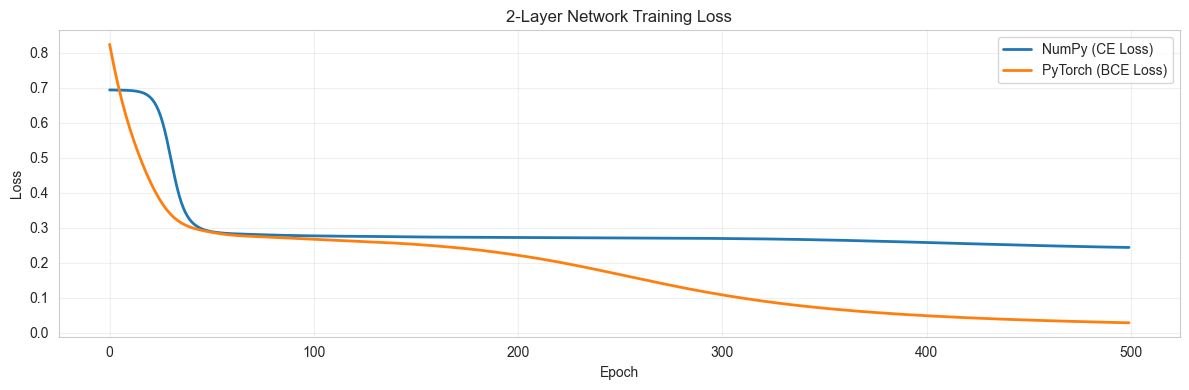

In [22]:
class TwoLayerNetTorch(nn.Module):
    """2-layer network in PyTorch"""
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.sigmoid(self.fc2(x))
        return x

# Convert to tensors
X_moons_torch = torch.FloatTensor(X_moons)
y_moons_torch = torch.FloatTensor(y_moons)

# Model and training
model_torch = TwoLayerNetTorch(input_size=2, hidden_size=16, output_size=1)
criterion = nn.BCELoss()
optimizer = optim.Adam(model_torch.parameters(), lr=0.01)

losses_nn_torch = []
for epoch in range(500):
    optimizer.zero_grad()
    outputs = model_torch(X_moons_torch)
    loss = criterion(outputs, y_moons_torch)
    loss.backward()
    optimizer.step()
    losses_nn_torch.append(loss.item())

with torch.no_grad():
    predictions_torch = (model_torch(X_moons_torch) > 0.5).float()
    accuracy_torch = (predictions_torch == y_moons_torch).float().mean().item()
    print(f'PyTorch 2-Layer Network - Training Accuracy: {accuracy_torch:.4f}')

# Comparison
plt.figure(figsize=(12, 4))
plt.plot(losses_nn_numpy, label='NumPy (CE Loss)', linewidth=2)
plt.plot(losses_nn_torch, label='PyTorch (BCE Loss)', linewidth=2)
plt.title('2-Layer Network Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Vanishing/Exploding Gradients Problem

### Demonstrate Gradient Flow in Deep Networks

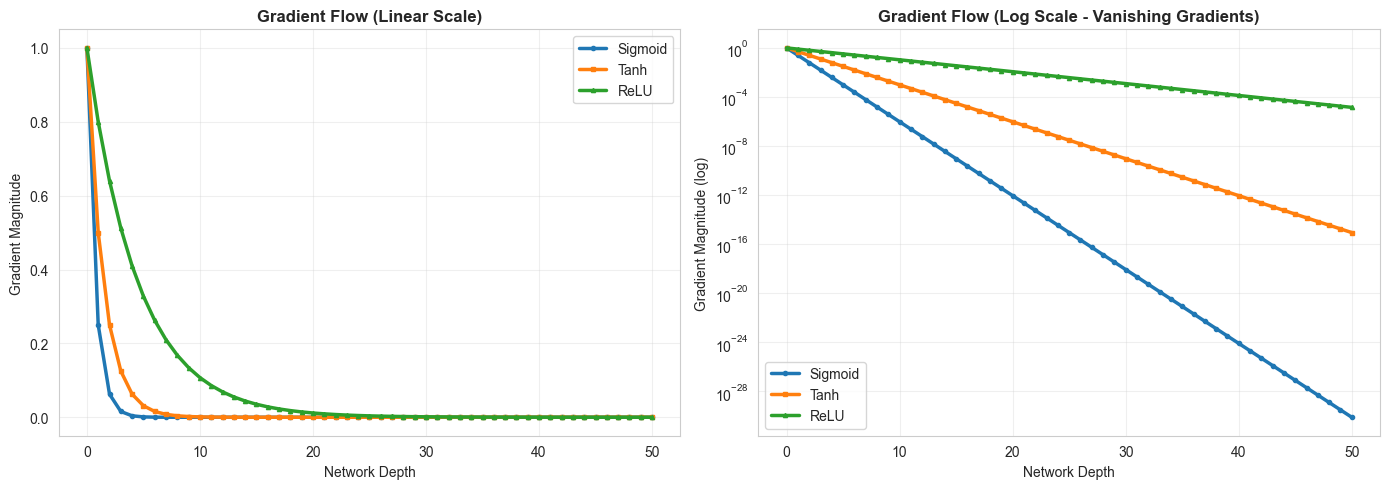

Sigmoid after 50 layers: 7.89e-31
Tanh after 50 layers: 8.88e-16
ReLU after 50 layers: 0.0000


In [23]:
# Analytical gradient flow simulation
def compute_gradient_flow(depth, activation_fn='sigmoid'):
    x = 1.0
    for _ in range(depth):
        if activation_fn == 'sigmoid':
            x = x * 0.25  # sigmoid derivative ≈ 0.25 max
        elif activation_fn == 'tanh':
            x = x * 0.5
        elif activation_fn == 'relu':
            x = x * 0.8  # ReLU preserves gradients better
    return x

depths = np.arange(0, 51)
grad_sigmoid = np.array([compute_gradient_flow(d, 'sigmoid') for d in depths])
grad_tanh = np.array([compute_gradient_flow(d, 'tanh') for d in depths])
grad_relu = np.array([compute_gradient_flow(d, 'relu') for d in depths])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear scale
axes[0].plot(depths, grad_sigmoid, linewidth=2.5, marker='o', markersize=3, label='Sigmoid')
axes[0].plot(depths, grad_tanh, linewidth=2.5, marker='s', markersize=3, label='Tanh')
axes[0].plot(depths, grad_relu, linewidth=2.5, marker='^', markersize=3, label='ReLU')
axes[0].set_title('Gradient Flow (Linear Scale)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Network Depth')
axes[0].set_ylabel('Gradient Magnitude')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Log scale
axes[1].semilogy(depths, grad_sigmoid, linewidth=2.5, marker='o', markersize=3, label='Sigmoid')
axes[1].semilogy(depths, grad_tanh, linewidth=2.5, marker='s', markersize=3, label='Tanh')
axes[1].semilogy(depths, grad_relu, linewidth=2.5, marker='^', markersize=3, label='ReLU')
axes[1].set_title('Gradient Flow (Log Scale - Vanishing Gradients)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Network Depth')
axes[1].set_ylabel('Gradient Magnitude (log)')
axes[1].legend()
axes[1].grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

print(f'Sigmoid after 50 layers: {grad_sigmoid[50]:.2e}')
print(f'Tanh after 50 layers: {grad_tanh[50]:.2e}')
print(f'ReLU after 50 layers: {grad_relu[50]:.4f}')

### Solutions: BatchNorm and Skip Connections (PyTorch)

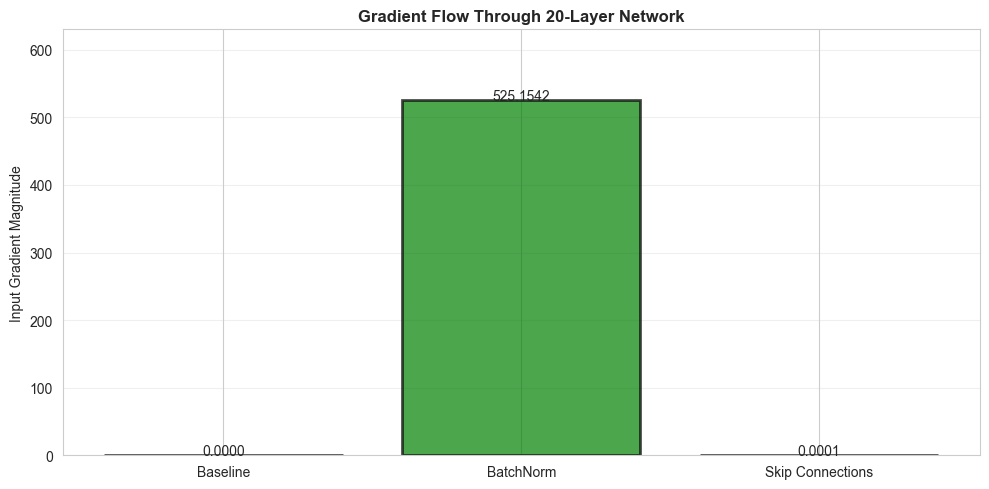


Gradient magnitudes at input layer:
  Baseline: 0.000000
  BatchNorm: 525.154175
  Skip Connections: 0.000104


In [24]:
class DeepNetBaseline(nn.Module):
    """Deep network WITHOUT BatchNorm or skip connections"""
    def __init__(self, depth=20):
        super().__init__()
        self.layers = nn.ModuleList([nn.Linear(10, 10) for _ in range(depth)])
        self.relu = nn.ReLU()
    
    def forward(self, x):
        for layer in self.layers:
            x = self.relu(layer(x))
        return x

class DeepNetWithBatchNorm(nn.Module):
    """Deep network WITH BatchNorm"""
    def __init__(self, depth=20):
        super().__init__()
        self.layers = nn.ModuleList([nn.Linear(10, 10) for _ in range(depth)])
        self.bns = nn.ModuleList([nn.BatchNorm1d(10) for _ in range(depth)])
        self.relu = nn.ReLU()
    
    def forward(self, x):
        for layer, bn in zip(self.layers, self.bns):
            x = self.relu(bn(layer(x)))
        return x

class DeepNetWithSkip(nn.Module):
    """Deep network WITH skip connections (residual)"""
    def __init__(self, depth=20):
        super().__init__()
        self.layers = nn.ModuleList([nn.Linear(10, 10) for _ in range(depth)])
        self.relu = nn.ReLU()
    
    def forward(self, x):
        for i, layer in enumerate(self.layers):
            residual = x
            x = self.relu(layer(x))
            if i % 2 == 1:  # Add skip every 2 layers
                x = x + residual
        return x

# Create random input
x_test = torch.randn(4, 10)

# Get gradient magnitudes for each model
models = {
    'Baseline': DeepNetBaseline(20),
    'BatchNorm': DeepNetWithBatchNorm(20),
    'Skip Connections': DeepNetWithSkip(20)
}

grad_magnitudes = {}

for name, model in models.items():
    model.train()
    x = x_test.clone().requires_grad_(True)
    output = model(x)
    loss = output.sum()
    loss.backward()
    grad_magnitudes[name] = x.grad.abs().mean().item()

plt.figure(figsize=(10, 5))
models_list = list(grad_magnitudes.keys())
values = list(grad_magnitudes.values())
bars = plt.bar(models_list, values, color=['red', 'green', 'blue'], alpha=0.7, edgecolor='black', linewidth=2)
plt.title('Gradient Flow Through 20-Layer Network', fontsize=12, fontweight='bold')
plt.ylabel('Input Gradient Magnitude')
plt.ylim(0, max(values) * 1.2)
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.4f}', ha='center')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print('\nGradient magnitudes at input layer:')
for name, mag in grad_magnitudes.items():
    print(f'  {name}: {mag:.6f}')

## 6. Regularization: Dropout and Weight Decay

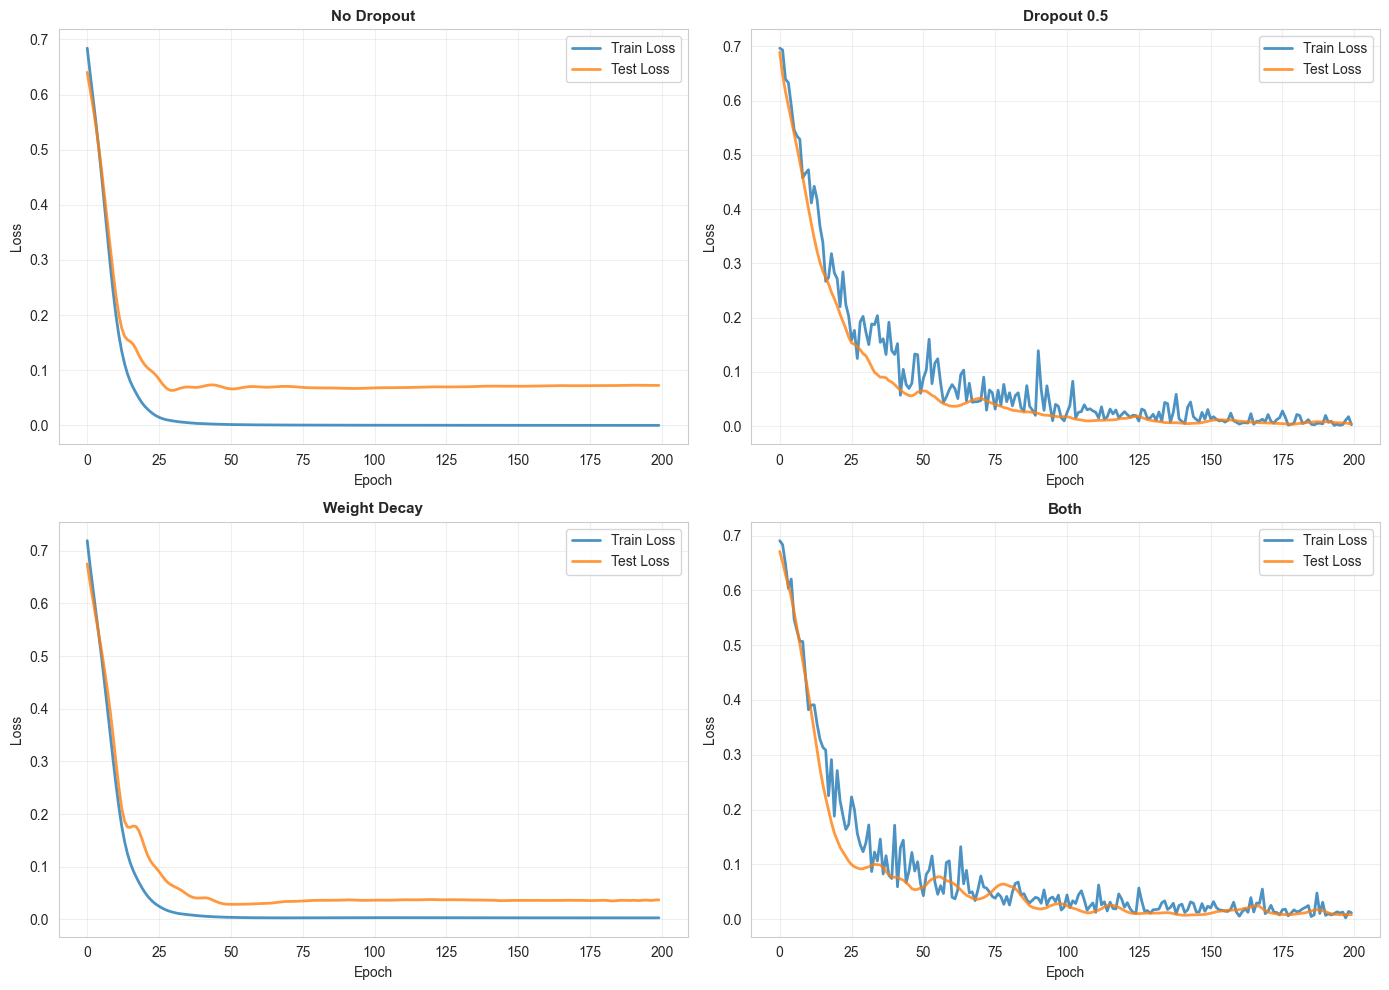


Regularization Impact (Final Losses):
No Dropout           | Train: 0.0001 | Test: 0.0725 | Gap: 0.0724
Dropout 0.5          | Train: 0.0025 | Test: 0.0042 | Gap: 0.0017
Weight Decay         | Train: 0.0028 | Test: 0.0370 | Gap: 0.0342
Both                 | Train: 0.0116 | Test: 0.0079 | Gap: -0.0037


In [25]:
class NetworkWithDropout(nn.Module):
    """Network with Dropout regularization"""
    def __init__(self, input_size, hidden_size, output_size, dropout_rate=0.5):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.dropout1 = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.dropout2 = nn.Dropout(dropout_rate)
        self.fc3 = nn.Linear(hidden_size, output_size)
        self.relu = nn.ReLU()
    
    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout1(x)  # Dropout after first hidden layer
        x = self.relu(self.fc2(x))
        x = self.dropout2(x)  # Dropout after second hidden layer
        x = self.fc3(x)
        return x

# Synthetic data (slightly overfit scenario)
np.random.seed(42)
X_train_synthetic = np.random.randn(100, 5)
y_train_synthetic = (X_train_synthetic[:, 0] > 0).astype(int)
X_test_synthetic = np.random.randn(50, 5)
y_test_synthetic = (X_test_synthetic[:, 0] > 0).astype(int)

X_train_t = torch.FloatTensor(X_train_synthetic)
y_train_t = torch.LongTensor(y_train_synthetic)
X_test_t = torch.FloatTensor(X_test_synthetic)
y_test_t = torch.LongTensor(y_test_synthetic)

# Train with and without dropout
configs = [
    ('No Dropout', 0.0, 0.0),
    ('Dropout 0.5', 0.5, 0.0),
    ('Weight Decay', 0.0, 0.001),
    ('Both', 0.5, 0.001)
]

results = {}

for config_name, dropout_rate, weight_decay in configs:
    model = NetworkWithDropout(input_size=5, hidden_size=32, output_size=2, dropout_rate=dropout_rate)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.01, weight_decay=weight_decay)
    
    train_losses = []
    test_losses = []
    
    for epoch in range(200):
        # Training
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train_t)
        loss = criterion(outputs, y_train_t)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())
        
        # Testing
        model.eval()
        with torch.no_grad():
            test_outputs = model(X_test_t)
            test_loss = criterion(test_outputs, y_test_t)
            test_losses.append(test_loss.item())
    
    results[config_name] = {
        'train': train_losses,
        'test': test_losses
    }

# Plot regularization effects
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, (config_name, losses) in enumerate(results.items()):
    ax = axes[idx // 2, idx % 2]
    ax.plot(losses['train'], label='Train Loss', linewidth=2, alpha=0.8)
    ax.plot(losses['test'], label='Test Loss', linewidth=2, alpha=0.8)
    ax.set_title(config_name, fontsize=11, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('\nRegularization Impact (Final Losses):')
for config_name, losses in results.items():
    train_final = losses['train'][-1]
    test_final = losses['test'][-1]
    gap = test_final - train_final
    print(f'{config_name:20} | Train: {train_final:.4f} | Test: {test_final:.4f} | Gap: {gap:.4f}')

## 7. Learning Rate Schedulers

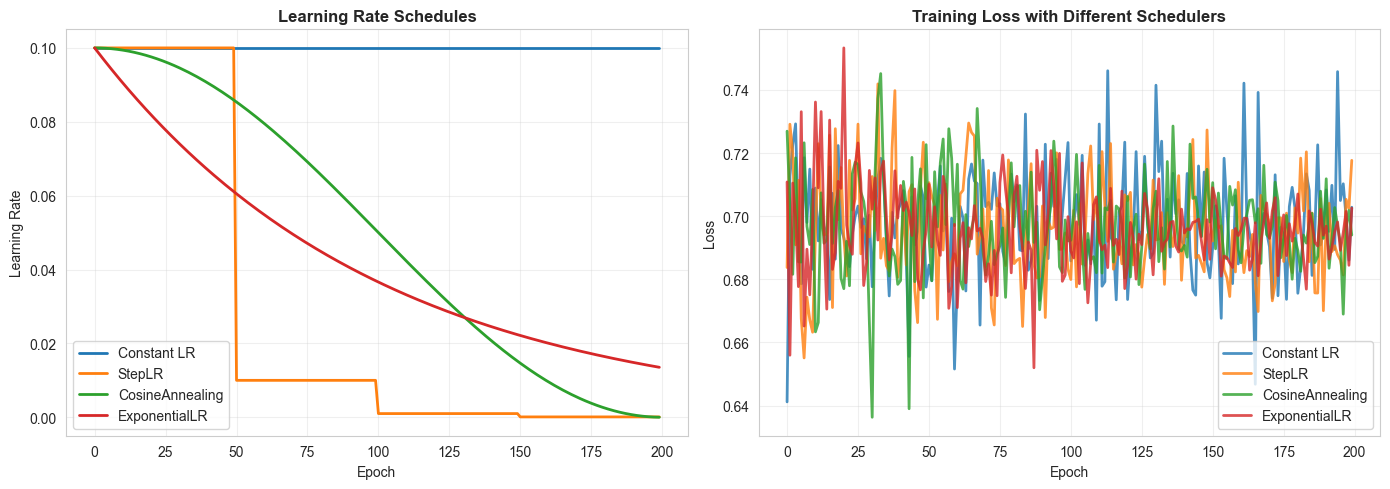

Learning rate scheduler comparison complete.


In [26]:
class SimpleNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(10, 32)
        self.fc2 = nn.Linear(32, 2)
    
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        return self.fc2(x)

# Define schedulers to compare
schedulers_config = [
    ('Constant LR', None),
    ('StepLR', lambda opt: optim.lr_scheduler.StepLR(opt, step_size=50, gamma=0.1)),
    ('CosineAnnealing', lambda opt: optim.lr_scheduler.CosineAnnealingLR(opt, T_max=200)),
    ('ExponentialLR', lambda opt: optim.lr_scheduler.ExponentialLR(opt, gamma=0.99))
]

scheduler_results = {}
learning_rates = {}

for scheduler_name, scheduler_fn in schedulers_config:
    model = SimpleNet()
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=0.1)
    
    if scheduler_fn:
        scheduler = scheduler_fn(optimizer)
    else:
        scheduler = None
    
    losses = []
    lrs = []
    
    for epoch in range(200):
        optimizer.zero_grad()
        X_batch = torch.randn(32, 10)
        y_batch = torch.randint(0, 2, (32,))
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        
        losses.append(loss.item())
        lrs.append(optimizer.param_groups[0]['lr'])
        
        if scheduler:
            scheduler.step()
    
    scheduler_results[scheduler_name] = losses
    learning_rates[scheduler_name] = lrs

# Plot learning rate schedules and training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Learning rates
for scheduler_name, lrs in learning_rates.items():
    axes[0].plot(lrs, label=scheduler_name, linewidth=2)
axes[0].set_title('Learning Rate Schedules', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Learning Rate')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Training losses
for scheduler_name, losses in scheduler_results.items():
    axes[1].plot(losses, label=scheduler_name, linewidth=2, alpha=0.8)
axes[1].set_title('Training Loss with Different Schedulers', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('Learning rate scheduler comparison complete.')

## 8. Train on Real Data with Decision Boundary Visualization

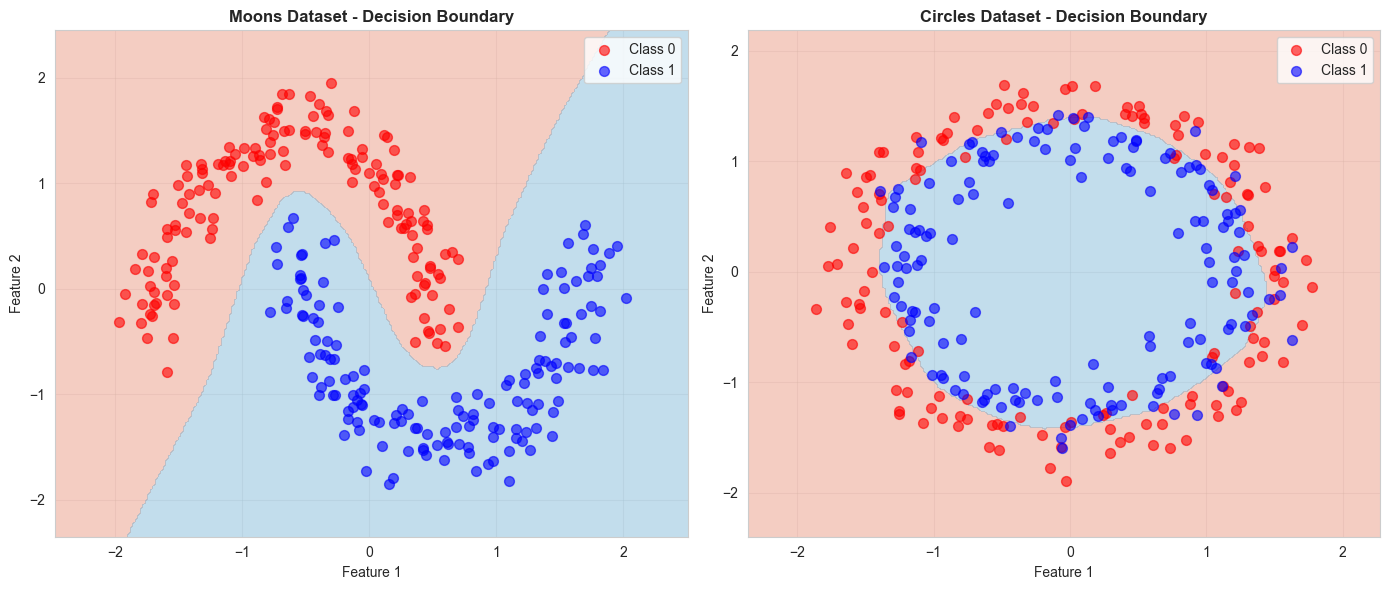

Moons - Accuracy: 1.0000
Circles - Accuracy: 0.8467


In [27]:
# Create classification datasets
datasets_dict = {}
for name, func in [('Moons', make_moons), ('Circles', make_circles)]:
    X, y = func(n_samples=300, noise=0.1, random_state=42)
    X = StandardScaler().fit_transform(X)
    datasets_dict[name] = (X, y)

# Train a model for each dataset
trained_models = {}
dataset_tensors = {}

for dataset_name, (X_data, y_data) in datasets_dict.items():
    X_tensor = torch.FloatTensor(X_data)
    y_tensor = torch.LongTensor(y_data)
    dataset_tensors[dataset_name] = (X_tensor, y_tensor)
    
    model = nn.Sequential(
        nn.Linear(2, 64),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(64, 64),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(64, 2)
    )
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.01, weight_decay=0.001)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=100, gamma=0.5)
    
    for epoch in range(300):
        optimizer.zero_grad()
        outputs = model(X_tensor)
        loss = criterion(outputs, y_tensor)
        loss.backward()
        optimizer.step()
        scheduler.step()
    
    trained_models[dataset_name] = model

# Visualize decision boundaries
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, (dataset_name, (X_data, y_data)) in enumerate(datasets_dict.items()):
    ax = axes[idx]
    model = trained_models[dataset_name]
    
    # Create mesh for decision boundary
    h = 0.02
    x_min, x_max = X_data[:, 0].min() - 0.5, X_data[:, 0].max() + 0.5
    y_min, y_max = X_data[:, 1].min() - 0.5, X_data[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    
    # Predict on mesh
    Z = np.c_[xx.ravel(), yy.ravel()]
    Z_tensor = torch.FloatTensor(Z)
    model.eval()
    with torch.no_grad():
        Z_pred = model(Z_tensor).argmax(dim=1).numpy()
    Z_pred = Z_pred.reshape(xx.shape)
    
    # Plot
    ax.contourf(xx, yy, Z_pred, levels=1, cmap='RdBu', alpha=0.4)
    ax.scatter(X_data[y_data == 0, 0], X_data[y_data == 0, 1], c='red', s=50, alpha=0.6, label='Class 0')
    ax.scatter(X_data[y_data == 1, 0], X_data[y_data == 1, 1], c='blue', s=50, alpha=0.6, label='Class 1')
    ax.set_title(f'{dataset_name} Dataset - Decision Boundary', fontsize=12, fontweight='bold')
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Evaluate accuracy
for dataset_name, (X_tensor, y_tensor) in dataset_tensors.items():
    model = trained_models[dataset_name]
    model.eval()
    with torch.no_grad():
        predictions = model(X_tensor).argmax(dim=1)
        accuracy = (predictions == y_tensor).float().mean().item()
        print(f'{dataset_name} - Accuracy: {accuracy:.4f}')

## 9. Interview Takeaways

In [28]:
takeaways = """
═══════════════════════════════════════════════════════════════════════════════
DEEP LEARNING FUNDAMENTALS - INTERVIEW TAKEAWAYS
═══════════════════════════════════════════════════════════════════════════════

1. ACTIVATION FUNCTIONS
   ├─ Sigmoid: Historical, causes vanishing gradients (derivative max 0.25)
   ├─ Tanh: Zero-centered, still has gradient issues (derivative max 1.0)
   ├─ ReLU: Default choice, computationally efficient, avoids saturation
   ├─ Leaky ReLU: Fixes "dying ReLU" where neurons output only zeros
   └─ GELU: Modern (used in Transformers), smoother than ReLU

2. PERCEPTRON & NEURAL NETWORKS
   ├─ Perceptron: Single neuron classifier with sigmoid activation
   ├─ Forward pass: linear combination → activation function
   ├─ Backward pass: compute gradients via chain rule (backpropagation)
   └─ Training: update weights using gradient descent

3. BACKPROPAGATION
   ├─ Chain rule: dL/dW = dL/dz * dz/dW
   ├─ Gradients flow backward from loss to input
   └─ Enables efficient training of deep networks

4. LOSS FUNCTIONS
   ├─ MSE: Regression, sensitive to outliers
   └─ Cross-Entropy: Classification, probabilistic interpretation

5. VANISHING/EXPLODING GRADIENT PROBLEM
   ├─ Issue: In deep networks, gradients shrink/explode during backprop
   ├─ Cause: Sigmoid/Tanh have small derivatives (max 0.25/1.0)
   ├─ Impact: Bottom layers barely update, slow/bad convergence
   └─ Solutions:
      ├─ Use ReLU (preserves gradient for x > 0)
      ├─ Batch Normalization (stabilizes activations)
      ├─ Skip/Residual connections (direct gradient paths)
      └─ Proper weight initialization (Xavier/He)

6. WEIGHT INITIALIZATION
   ├─ Poor init → training instability or divergence
   ├─ Xavier (Glorot): Variance = 1/input_size (for Sigmoid/Tanh)
   ├─ He: Variance = 2/input_size (for ReLU)
   └─ Modern: Often replaced by BatchNorm, which makes init less critical

7. REGULARIZATION
   ├─ Dropout: Randomly disable neurons during training (prevent co-adaptation)
   │  └─ Effect: Approximates ensemble of networks
   └─ Weight Decay (L2): Penalize large weights in loss function
      └─ Effect: Simpler model, better generalization

8. LEARNING RATE SCHEDULING
   ├─ Constant LR: Simple, may overshoot or get stuck
   ├─ StepLR: Reduce by factor every N steps (discrete drops)
   ├─ CosineAnnealing: Smooth decay to near-zero (good for fine-tuning)
   └─ ExponentialLR: Exponential decay (smooth, flexible)

9. BATCH NORMALIZATION
   ├─ Normalizes layer inputs to zero mean, unit variance
   ├─ Benefits: Reduces internal covariate shift, enables higher LR
   ├─ Reduces sensitivity to weight initialization
   └─ Provides slight regularization effect

10. SKIP CONNECTIONS (RESIDUAL NETWORKS)
    ├─ Direct path for gradients: x + f(x)
    ├─ Allows training very deep networks (50+ layers)
    └─ Identity mapping preserves gradient flow

11. PRACTICAL TRAINING TIPS
    ├─ Normalize input data (zero mean, unit variance)
    ├─ Use Adam or SGD+momentum as optimizers
    ├─ Monitor train/validation loss for overfitting
    ├─ Start with simple architecture, gradually increase complexity
    ├─ Use validation set for hyperparameter tuning
    └─ Save best model based on validation performance

12. NUMPY VS PYTORCH
    ├─ NumPy: Educational, understand mechanics, slow for large data
    ├─ PyTorch: Production-ready, automatic differentiation, GPU support
    ├─ PyTorch has optimizers, schedulers, modules built-in
    └─ Both teach same concepts; PyTorch is practical choice

═══════════════════════════════════════════════════════════════════════════════
"""

print(takeaways)


═══════════════════════════════════════════════════════════════════════════════
DEEP LEARNING FUNDAMENTALS - INTERVIEW TAKEAWAYS
═══════════════════════════════════════════════════════════════════════════════

1. ACTIVATION FUNCTIONS
   ├─ Sigmoid: Historical, causes vanishing gradients (derivative max 0.25)
   ├─ Tanh: Zero-centered, still has gradient issues (derivative max 1.0)
   ├─ ReLU: Default choice, computationally efficient, avoids saturation
   ├─ Leaky ReLU: Fixes "dying ReLU" where neurons output only zeros
   └─ GELU: Modern (used in Transformers), smoother than ReLU

2. PERCEPTRON & NEURAL NETWORKS
   ├─ Perceptron: Single neuron classifier with sigmoid activation
   ├─ Forward pass: linear combination → activation function
   ├─ Backward pass: compute gradients via chain rule (backpropagation)
   └─ Training: update weights using gradient descent

3. BACKPROPAGATION
   ├─ Chain rule: dL/dW = dL/dz * dz/dW
   ├─ Gradients flow backward from loss to input
   └─ Enables e

---

<small><em>© 2026 AI Nirvana · More Info: https://medium.com/@snigam/a-simple-structured-way-to-prepare-for-ai-ml-interviews-68b2e5830195 · Disclaimer: Provided as is. No liability assumed.</em></small>